## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

print('✅ Libraries imported!')

✅ Libraries imported!


## Load Dataset

In [2]:
df = pd.read_csv('../data/cleaned_freelance_jobs.csv')
print(f'✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 5,000 rows, 20 columns


,project_budget,client_rating,num_existing_proposals,freelancer_experience,proposal_quality_score,project_category,client_location,project_duration,freelancer_country,freelancer_rating,previous_jobs_completed,budget_per_proposal,project_category_encoded,client_location_encoded,freelancer_country_encoded,client_rating_category_encoded,experience_level_encoded,experience_quality_interaction,combined_experience_rating,success
0,16295.0,1.9,8.0,17,4.0,Writing,Brazil,61.0,Nigeria,2.6,61,1810.555556,5,1,4,1,1,68.0,24.44,1
1,1360.0,4.8,61.0,15,2.0,Marketing,France,62.0,USA,2.3,318,21.935484,2,3,8,0,1,30.0,100.82,0
2,38658.0,1.2,85.0,10,8.0,Data Science,France,53.0,India,4.9,311,449.511628,0,3,3,1,3,80.0,98.26,1
3,45232.0,2.8,46.0,9,8.0,Marketing,Germany,53.0,Nigeria,3.9,38,962.382979,2,4,4,2,3,72.0,15.66,1
4,11784.0,1.3,4.0,8,1.0,Writing,Singapore,28.0,UK,2.5,59,2356.800000,5,6,7,1,3,8.0,21.10,0


## Define Features & Target

In [3]:
y = df['success']

exclude_cols = ['success', 'project_category', 'client_location', 'freelancer_country']
exclude_cols = [c for c in exclude_cols if c in df.columns]

X = df.drop(columns=exclude_cols).select_dtypes(include=['int64', 'float64'])

print(f'📊 Features: {X.shape[1]} columns, {X.shape[0]:,} rows')
print(f'🎯 Success rate: {y.mean()*100:.1f}%')
print(f'📋 Feature list: {list(X.columns)}')

📊 Features: 16 columns, 5,000 rows
🎯 Success rate: 40.0%
📋 Feature list: ['project_budget', 'client_rating', 'num_existing_proposals', 'freelancer_experience', 'proposal_quality_score', 'project_duration', 'freelancer_rating', 'previous_jobs_completed', 'budget_per_proposal', 'project_category_encoded', 'client_location_encoded', 'freelancer_country_encoded', 'client_rating_category_encoded', 'experience_level_encoded', 'experience_quality_interaction', 'combined_experience_rating']


## Train / Validation / Test Split

In [4]:
# First split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: carve 20% of train as validation (for threshold tuning)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f'📊 Train:      {X_tr.shape[0]:,} samples')
print(f'📊 Validation: {X_val.shape[0]:,} samples')
print(f'📊 Test:       {X_test.shape[0]:,} samples')

📊 Train:      3,200 samples
📊 Validation: 800 samples
📊 Test:       1,000 samples


## Feature Engineering

In [5]:
def add_features(df):
    df = df.copy()
    cols = df.columns.tolist()

    # Interaction features
    pairs = [
        ('proposal_quality_score', 'freelancer_rating'),
        ('proposal_quality_score', 'freelancer_experience'),
        ('client_rating', 'freelancer_rating'),
    ]
    for c1, c2 in pairs:
        if c1 in cols and c2 in cols:
            df[f'{c1}_x_{c2}'] = df[c1] * df[c2]

    # Ratio features
    if 'freelancer_rating' in cols and 'num_existing_proposals' in cols:
        df['rating_per_proposal'] = df['freelancer_rating'] / (df['num_existing_proposals'] + 1)

    return df

X_tr   = add_features(X_tr)
X_val  = add_features(X_val)
X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f'✅ Features after engineering: {X_tr.shape[1]}')

✅ Features after engineering: 20


## Feature Scaling

In [6]:
scaler = StandardScaler()

# Fit on train subset only — no leakage
X_tr_sc    = scaler.fit_transform(X_tr)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Full train (for final retraining after threshold is chosen)
scaler_full = StandardScaler()
X_train_sc = scaler_full.fit_transform(X_train)
X_test_sc_full = scaler_full.transform(X_test)

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler_full, '../models/scaler.pkl')
print('✅ Scaler saved!')

✅ Scaler saved!


## Define Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(
        C=10, max_iter=3000, class_weight='balanced', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=2,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
}

print(f'✅ {len(models)} models defined')

✅ 4 models defined


## Train & Evaluate with Threshold Tuning

In [8]:
def tune_threshold(model, X_val, y_val):
    """Find best F1 threshold using validation set (no data leakage)"""
    proba = model.predict_proba(X_val)[:, 1]
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.20, 0.80, 0.01):
        pred = (proba >= t).astype(int)
        f1   = f1_score(y_val, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t


results_list   = []
trained_models = {}
best_thresholds = {}

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')

    # Step 1: Train on train subset → find best threshold on val set
    model.fit(X_tr_sc, y_tr)
    best_t = tune_threshold(model, X_val_sc, y_val)

    # Step 2: Retrain on full train set
    model.fit(X_train_sc, y_train)
    y_proba = model.predict_proba(X_test_sc_full)[:, 1]
    y_pred  = (y_proba >= best_t).astype(int)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1').mean()

    results = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1 Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'CV F1':     cv_f1,
        'Threshold': best_t,
    }
    results_list.append(results)
    trained_models[name]  = model
    best_thresholds[name] = best_t

    joblib.dump(model, f'../models/{name.lower().replace(" ", "_")}.pkl')

    print(f'✅ F1:        {results["F1 Score"]:.4f}')
    print(f'✅ Accuracy:  {results["Accuracy"]:.4f}')
    print(f'✅ ROC-AUC:   {results["ROC-AUC"]:.4f}')
    print(f'✅ CV F1:     {results["CV F1"]:.4f}')
    print(f'✅ Threshold: {results["Threshold"]:.2f}')


Training: Logistic Regression
✅ F1:        0.8753
✅ Accuracy:  0.8980
✅ ROC-AUC:   0.9652
✅ CV F1:     0.8779
✅ Threshold: 0.46

Training: Decision Tree
✅ F1:        0.8532
✅ Accuracy:  0.8840
✅ ROC-AUC:   0.9386
✅ CV F1:     0.8441
✅ Threshold: 0.55

Training: Random Forest
✅ F1:        0.8764
✅ Accuracy:  0.8990
✅ ROC-AUC:   0.9610
✅ CV F1:     0.8686
✅ Threshold: 0.40

Training: Gradient Boosting
✅ F1:        0.8692
✅ Accuracy:  0.8920
✅ ROC-AUC:   0.9627
✅ CV F1:     0.8690
✅ Threshold: 0.33


## Model Comparison

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC    CV F1  Threshold
      Random Forest     0.899   0.858513  0.8950  0.876377 0.960958 0.868610       0.40
Logistic Regression     0.898   0.856459  0.8950  0.875306 0.965175 0.877916       0.46
  Gradient Boosting     0.892   0.842723  0.8975  0.869249 0.962742 0.869006       0.33
      Decision Tree     0.884   0.864103  0.8425  0.853165 0.938606 0.844100       0.55


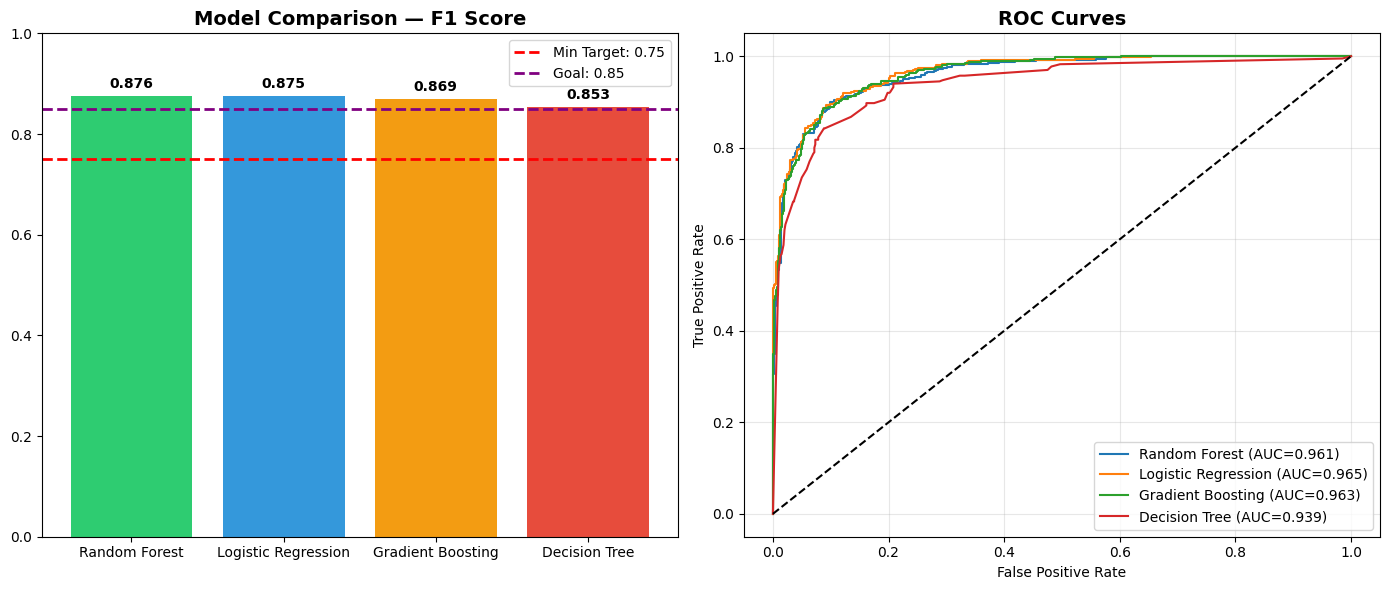

In [9]:
results_df = pd.DataFrame(results_list).sort_values('F1 Score', ascending=False)
print(results_df.to_string(index=False))

os.makedirs('../plots', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Bar Chart
ax1 = axes[0]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax1.bar(results_df['Model'], results_df['F1 Score'], color=colors)
ax1.axhline(y=0.75, color='red',    linestyle='--', linewidth=2, label='Min Target: 0.75')
ax1.axhline(y=0.85, color='purple', linestyle='--', linewidth=2, label='Goal: 0.85')
ax1.set_title('Model Comparison — F1 Score', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.legend()
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.01,
             f'{h:.3f}', ha='center', va='bottom', fontweight='bold')

# ROC Curves
ax2 = axes[1]
for name in results_df['Model']:
    y_prob = trained_models[name].predict_proba(X_test_sc_full)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax2.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/model_comparison_improved.png', dpi=300, bbox_inches='tight')
plt.show()

## Best Model & Confusion Matrix

🏆 Best Model:  Random Forest
📊 F1 Score:    0.8764
📊 Threshold:   0.40
✅ GOAL ACHIEVED! F1 >= 0.85


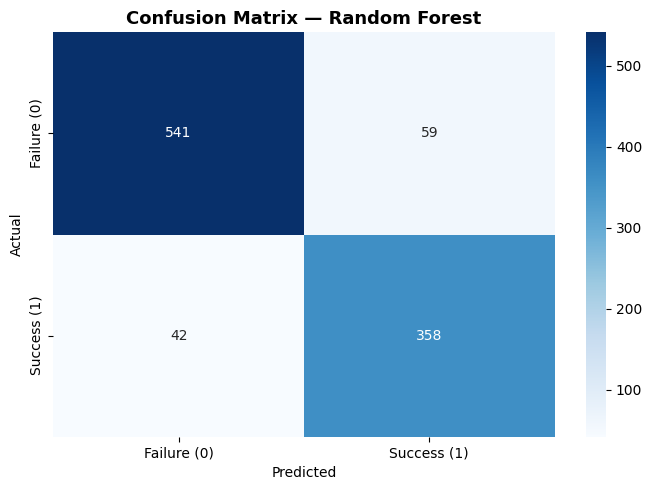


               precision    recall  f1-score   support

     Failure       0.93      0.90      0.91       600
     Success       0.86      0.90      0.88       400

    accuracy                           0.90      1000
   macro avg       0.89      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [10]:
best_name  = results_df.iloc[0]['Model']
best_f1    = results_df.iloc[0]['F1 Score']
best_t     = best_thresholds[best_name]
best_model = trained_models[best_name]

print(f'🏆 Best Model:  {best_name}')
print(f'📊 F1 Score:    {best_f1:.4f}')
print(f'📊 Threshold:   {best_t:.2f}')

if best_f1 >= 0.85:
    print('✅ GOAL ACHIEVED! F1 >= 0.85')
elif best_f1 >= 0.75:
    print('✅ TARGET ACHIEVED! F1 >= 0.75')
else:
    print(f'⚠️  F1 = {best_f1:.4f} — below target')

# Confusion Matrix
y_proba_best = best_model.predict_proba(X_test_sc_full)[:, 1]
y_pred_best  = (y_proba_best >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Failure (0)', 'Success (1)'],
            yticklabels=['Failure (0)', 'Success (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/confusion_matrix_improved.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n', classification_report(y_test, y_pred_best, target_names=['Failure', 'Success']))

## Save Best Model

In [11]:
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(best_t,     '../models/best_threshold.pkl')

print('✅ Best model saved:     ../models/best_model.pkl')
print('✅ Best threshold saved: ../models/best_threshold.pkl')
print('✅ Scaler saved:         ../models/scaler.pkl')

✅ Best model saved:     ../models/best_model.pkl
✅ Best threshold saved: ../models/best_threshold.pkl
✅ Scaler saved:         ../models/scaler.pkl


## Final Summary

In [12]:
print('=' * 60)
print('PHASE 3 — FINAL SUMMARY')
print('=' * 60)
print(f'\n🏆 Best Model:  {best_name}')
print(f'📊 F1 Score:    {best_f1:.4f}')
print(f'📊 Threshold:   {best_t:.2f}')

if best_f1 >= 0.85:
    status = '✅ GOAL ACHIEVED (F1 >= 0.85)'
elif best_f1 >= 0.75:
    status = '✅ TARGET ACHIEVED (F1 >= 0.75)'
else:
    status = '⚠️  BELOW TARGET'

print(f'📊 Status: {status}')
print('\n📁 Files Saved:')
print('   ✅ ../models/best_model.pkl')
print('   ✅ ../models/best_threshold.pkl')
print('   ✅ ../models/scaler.pkl')
print('   ✅ ../plots/model_comparison_improved.png')
print('   ✅ ../plots/confusion_matrix_improved.png')
print('\n' + '=' * 60)
print('✅ PHASE 3 COMPLETED!')
print('🚀 READY FOR PHASE 4 — RECOMMENDATION ENGINE')
print('=' * 60)

PHASE 3 — FINAL SUMMARY

🏆 Best Model:  Random Forest
📊 F1 Score:    0.8764
📊 Threshold:   0.40
📊 Status: ✅ GOAL ACHIEVED (F1 >= 0.85)

📁 Files Saved:
   ✅ ../models/best_model.pkl
   ✅ ../models/best_threshold.pkl
   ✅ ../models/scaler.pkl
   ✅ ../plots/model_comparison_improved.png
   ✅ ../plots/confusion_matrix_improved.png

✅ PHASE 3 COMPLETED!
🚀 READY FOR PHASE 4 — RECOMMENDATION ENGINE
